In [1]:
import numpy as np
import os
import json
from zipfile import ZipFile
from PIL import Image
import matplotlib.pyplot as plt
from tensorflow import keras
from keras import layers, models

2025-03-07 12:15:37.955927: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-07 12:15:37.969390: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-07 12:15:37.986031: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-07 12:15:37.991731: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-07 12:15:38.005698: I tensorflow/core/platform/cpu_feature_guar

In [2]:
import os
import numpy as np
from glob import glob
from keras.preprocessing import image
from sklearn.model_selection import train_test_split

input_dir = "/home/gourib/LIDC-IDRI-slices"
img_shape = (128,128)  # Adjust according to your requirement
Thres = 100  # Threshold for segmentation mask

images = []
masks = []
y = []

# Step 1: Get all patient IDs
patients = sorted(os.listdir(input_dir))

# Step 2: Split patients into train and test sets
train_patients, test_patients = train_test_split(patients, train_size=0.8, random_state=12)

def load_patient_data(patient_list):
    """Load images and masks for the given list of patients"""
    images, masks, labels = [], [], []
    
    for patient in patient_list:
        patient_path = os.path.join(input_dir, patient)
        
        for nodule in os.listdir(patient_path):
            mask0, mask1, mask2, mask3 = [], [], [], []

            # Load images
            for filename in glob(f"{patient_path}/{nodule}/images/*.png"):
                img = image.load_img(filename, target_size=img_shape)
                images.append(np.asarray(img))

            # Load masks
            for filename in glob(f"{patient_path}/{nodule}/mask-0/*.png"):
                img = image.load_img(filename, target_size=img_shape)
                mask1.append(np.asarray(img))

            # Determine final mask selection
            for i in range(len(mask1)):
                white_sum = mask1[i].sum()
                label = 1 if white_sum > Thres else 0
                
                labels.append(label)
                masks.append(mask1[i])
    
    return images, masks, labels

# Step 3: Load training and testing data based on patient-wise split
x_train, mask_train, y_train = load_patient_data(train_patients)
x_test, mask_test, y_test = load_patient_data(test_patients)

# Convert to NumPy arrays
x_train, x_test = np.array(x_train)/255, np.array(x_test)/255
mask_train, mask_test = np.array(mask_train)/255, np.array(mask_test)/255
y_train, y_test = np.array(y_train), np.array(y_test)

# Print shapes
print(x_train.shape, x_test.shape)
print(mask_train.shape, mask_test.shape)

(12052, 128, 128, 3) (3496, 128, 128, 3)
(12052, 128, 128, 3) (3496, 128, 128, 3)


In [3]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential,load_model
from keras import layers
from keras.layers import Dense, Activation, Flatten, Dropout, BatchNormalization,Embedding,TimeDistributed
from keras.layers import Conv2D, MaxPooling2D, ReLU, LSTM,Bidirectional,Attention,Concatenate,concatenate
from keras import regularizers, optimizers,losses
from keras.layers import DepthwiseConv2D,Add, ReLU, GlobalAveragePooling2D, GlobalMaxPooling2D,MultiHeadAttention
from keras.layers import Activation,ActivityRegularization, AvgPool2D, LeakyReLU, Conv2DTranspose
from keras.metrics import Accuracy,Recall,Precision,AUC,TruePositives,TrueNegatives,FalseNegatives,FalsePositives, SpecificityAtSensitivity,SensitivityAtSpecificity
from keras.utils import plot_model
from keras.preprocessing import image
from keras.utils import to_categorical
import numpy as np
import matplotlib
import sklearn
import matplotlib.pyplot as plt
import time
import os
import sklearn.metrics as m
from glob import glob
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import tree
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

In [13]:
# import tensorflow as tf
# from keras.applications import MobileNetV2
# from keras.layers import (Conv2D, Conv2DTranspose, Dropout, BatchNormalization, concatenate, Input)
# from keras.models import Model

# Name = "MobileNetV2_U-NetPP"

# def conv_block(inputs, num_filters, dropout_rate=0.3):
#     x = Conv2D(num_filters, (3, 3), activation="relu", padding="same")(inputs)
#     x = BatchNormalization()(x)
#     x = Dropout(dropout_rate)(x)
#     x = Conv2D(num_filters, (3, 3), activation="relu", padding="same")(x)
#     x = BatchNormalization()(x)
#     x = Dropout(dropout_rate)(x)
#     return x

# def mobilenet_unetpp():
#     img_shape = (128, 128, 3)
#     mobilenet = MobileNetV2(include_top=False, weights="imagenet", input_shape=img_shape)
    
#     for layer in mobilenet.layers:
#         layer.trainable = False

#     # Encoder (MobileNetV2 features)
#     c1 = mobilenet.get_layer("block_1_expand_relu").output  # 64x64
#     c2 = mobilenet.get_layer("block_3_expand_relu").output  # 32x32
#     c3 = mobilenet.get_layer("block_6_expand_relu").output  # 16x16
#     c4 = mobilenet.get_layer("block_13_expand_relu").output # 8x8
#     c5 = mobilenet.get_layer("block_16_project").output     # 4x4 (Bottleneck)

#     # Nested Decoder (UNet++)
#     d4_1 = conv_block(c4, 256)
#     d3_1 = conv_block(c3, 128)
#     d3_2 = conv_block(concatenate([d3_1, Conv2DTranspose(128, (2, 2), strides=(2, 2), padding="same")(d4_1)]), 128)
#     d2_1 = conv_block(c2, 64)
#     d2_2 = conv_block(concatenate([d2_1, Conv2DTranspose(64, (2, 2), strides=(2, 2), padding="same")(d3_1)]), 64)
#     d2_3 = conv_block(concatenate([d2_1, d2_2, Conv2DTranspose(64, (2, 2), strides=(2, 2), padding="same")(d3_2)]), 64)
#     d1_1 = conv_block(c1, 32)
#     d1_2 = conv_block(concatenate([d1_1, Conv2DTranspose(32, (2, 2), strides=(2, 2), padding="same")(d2_1)]), 32)
#     d1_3 = conv_block(concatenate([d1_1, d1_2, Conv2DTranspose(32, (2, 2), strides=(2, 2), padding="same")(d2_2)]), 32)
#     d1_4 = conv_block(concatenate([d1_1, d1_2, d1_3, Conv2DTranspose(32, (2, 2), strides=(2, 2), padding="same")(d2_3)]), 32)
    
#     # Final upsampling and output
#     u0_1 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding="same")(d1_4)
#     c0_1 = conv_block(u0_1, 16, dropout_rate=0.2)
#     outputs = Conv2D(3, (1, 1), activation="sigmoid")(c0_1)
    
#     model = Model(inputs=mobilenet.input, outputs=outputs, name="MobileNetV2_UNetPlusPlus")
#     return model

# # Create the model
# unetpp_model = mobilenet_unetpp()
# unetpp_model.summary()


Dropout

In [14]:
import tensorflow as tf
from keras.applications import MobileNetV2
from keras.layers import (Conv2D, Conv2DTranspose, Dropout, BatchNormalization, concatenate, Input)
from keras.models import Model

Name = "MobileNetV2_U-NetPP"

def conv_block(inputs, num_filters, dropout_rate=0.3):
    x = Conv2D(num_filters, (3, 3), activation="relu", padding="same")(inputs)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)
    x = Conv2D(num_filters, (3, 3), activation="relu", padding="same")(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)
    return x

def mobilenet_unetpp():
    img_shape = (128, 128, 3)
    mobilenet = MobileNetV2(include_top=False, weights="imagenet", input_shape=img_shape)
    
    for layer in mobilenet.layers:
        layer.trainable = False

    # Encoder (MobileNetV2 features)
    c1 = mobilenet.get_layer("block_1_expand_relu").output  # 64x64
    c2 = mobilenet.get_layer("block_3_expand_relu").output  # 32x32
    c3 = mobilenet.get_layer("block_6_expand_relu").output  # 16x16
    c4 = mobilenet.get_layer("block_13_expand_relu").output # 8x8
    c5 = mobilenet.get_layer("block_16_project").output     # 4x4 (Bottleneck)

    # Nested Decoder (UNet++)
    d4_1 = conv_block(c4, 256)
    d3_1 = conv_block(c3, 128)
    d3_2 = conv_block(concatenate([d3_1, Conv2DTranspose(128, (2, 2), strides=(2, 2), padding="same")(d4_1)]), 128)
    d2_1 = conv_block(c2, 64)
    d2_2 = conv_block(concatenate([d2_1, Conv2DTranspose(64, (2, 2), strides=(2, 2), padding="same")(d3_1)]), 64)
    d2_3 = conv_block(concatenate([d2_1, d2_2, Conv2DTranspose(64, (2, 2), strides=(2, 2), padding="same")(d3_2)]), 64)
    d1_1 = conv_block(c1, 32)
    d1_2 = conv_block(concatenate([d1_1, Conv2DTranspose(32, (2, 2), strides=(2, 2), padding="same")(d2_1)]), 32)
    d1_3 = conv_block(concatenate([d1_1, d1_2, Conv2DTranspose(32, (2, 2), strides=(2, 2), padding="same")(d2_2)]), 32)
    d1_4 = conv_block(concatenate([d1_1, d1_2, d1_3, Conv2DTranspose(32, (2, 2), strides=(2, 2), padding="same")(d2_3)]), 32)
    
    # Final upsampling and output
    u0_1 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding="same")(d1_4)
    c0_1 = conv_block(u0_1, 16, dropout_rate=0.2)
    outputs = Conv2D(3, (1, 1), activation="sigmoid")(c0_1)
    
    model = Model(inputs=mobilenet.input, outputs=outputs, name="MobileNetV2_UNetPlusPlus")
    return model

# Create the model
unetpp_model = mobilenet_unetpp()
unetpp_model.summary()


Model: "MobileNetV2_UNetPlusPlus"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 4,106,243 (15.66 MB)

 Trainable params: 3,486,595 (13.30 MB)

 Non-trainable params: 619,648 (2.36 MB)

In [ ]:
def dice_coef(y_true, y_pred, smooth=1e-6):
        y_true_f = tf.keras.backend.flatten(y_true)
        y_pred_f = tf.keras.backend.flatten(y_pred)
        intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
        return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

# IoU (Jaccard Index)
def iou_coef(y_true, y_pred, smooth=1e-6):
        y_true_f = tf.keras.backend.flatten(y_true)
        y_pred_f = tf.keras.backend.flatten(y_pred)
        intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
        union = tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) - intersection
        return (intersection + smooth) / (union + smooth)

def dice_loss(y_true, y_pred):
    smooth = 1.
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

# Model Compilation
model= mobilenet_unetpp()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), 
        loss=dice_loss, 
        metrics=[dice_coef, iou_coef, tf.keras.metrics.Recall(), tf.keras.metrics.Precision()])
#model.summary()


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
checkpointer = ModelCheckpoint(Name + '_checkpoint.weights.h5', verbose=1, save_best_only=True, save_weights_only=True)


In [ ]:
early_stopping = EarlyStopping(monitor='val_dice_coeff', patience=5, verbose=1, restore_best_weights=True)

In [ ]:
print(x_train.shape, mask_train.shape)

(12052, 128, 128, 3) (12052, 128, 128, 3)


In [ ]:
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint

results = model.fit(
    x_train, mask_train, 
    validation_split=0.2, 
    batch_size=32, 
    epochs=300, 
    callbacks=[early_stopping, checkpointer]
)

Epoch 1/300


2025-03-06 12:49:18.152627: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'input_multiply_reduce_transpose_fusion_1', 8 bytes spill stores, 120 bytes spill loads



301/302 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - dice_coef: 0.4252 - iou_coef: 0.3144 - loss: 0.5748 - precision_1: 0.1162 - recall_1: 0.7705

2025-03-06 12:50:03.687719: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_118', 4 bytes spill stores, 4 bytes spill loads



302/302 ━━━━━━━━━━━━━━━━━━━━ 98s 178ms/step - dice_coef: 0.4265 - iou_coef: 0.3154 - loss: 0.5735 - precision_1: 0.1168 - recall_1: 0.7702 - val_dice_coef: 0.2424 - val_iou_coef: 0.1431 - val_loss: 0.7579 - val_precision_1: 0.1556 - val_recall_1: 0.9644
Epoch 2/300
302/302 ━━━━━━━━━━━━━━━━━━━━ 18s 60ms/step - dice_coef: 0.7428 - iou_coef: 0.5944 - loss: 0.2571 - precision_1: 0.7565 - recall_1: 0.7437 - val_dice_coef: 0.6641 - val_iou_coef: 0.5129 - val_loss: 0.3363 - val_precision_1: 0.6322 - val_recall_1: 0.8020
Epoch 3/300
302/302 ━━━━━━━━━━━━━━━━━━━━ 18s 61ms/step - dice_coef: 0.7758 - iou_coef: 0.6363 - loss: 0.2241 - precision_1: 0.7903 - recall_1: 0.7732 - val_dice_coef: 0.6961 - val_iou_coef: 0.5503 - val_loss: 0.3042 - val_precision_1: 0.7545 - val_recall_1: 0.7171
Epoch 4/300
302/302 ━━━━━━━━━━━━━━━━━━━━ 18s 59ms/step - dice_coef: 0.7812 - iou_coef: 0.6440 - loss: 0.2188 - precision_1: 0.8039 - recall_1: 0.7734 - val_dice_coef: 0.6574 - val_iou_coef: 0.5080 - val_loss: 0.3432 

KeyboardInterrupt: 

In [19]:
test_results = model.evaluate(x_test, mask_test, batch_size=32)
print("Test Metrics:", test_results)

110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - dice_coef: 0.7237 - iou_coef: 0.5879 - loss: 0.2763 - precision_1: 0.7509 - recall_1: 0.7786
Test Metrics: [0.2486206293106079, 0.7516947388648987, 0.6136966943740845, 0.7745547294616699, 0.7752203941345215]


In [20]:
predictions = model.predict(x_test)

110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step


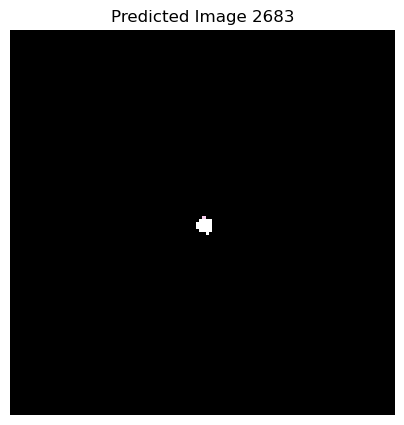

In [26]:
i = np.random.randint(len(mask_test))
# Display the selected ground truth and predicted mask
plt.figure(figsize=(5, 5))
plt.imshow(predictions[i], cmap='gray')  # Change to `mask_train[i]` to see the ground truth
plt.title(f"Predicted Image {i}")
plt.axis("off")
plt.show()

In [8]:
import tensorflow as tf
from keras.applications import MobileNetV2
from keras.layers import Conv2D, UpSampling2D, Input
from keras.models import Model
import keras.backend as K

# Function to load DeepLabV3+ with a specific input shape
def DeeplabV3Plus(input_shape=(128, 128, 3), num_classes=3):
    base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights="imagenet")
    
    # Extract encoder features
    x = base_model.output  # (4x4)

    # Add ASPP (Atrous Spatial Pyramid Pooling)
    x = Conv2D(256, (1, 1), activation='relu', padding="same")(x)
    x = UpSampling2D(size=(2, 2), interpolation="bilinear")(x)  # (8x8)

    # Decoder: Upsample step by step
    x = UpSampling2D(size=(2, 2), interpolation="bilinear")(x)  # (16x16)
    x = UpSampling2D(size=(2, 2), interpolation="bilinear")(x)  # (32x32)
    x = UpSampling2D(size=(2, 2), interpolation="bilinear")(x)  # (64x64)
    x = UpSampling2D(size=(2, 2), interpolation="bilinear")(x)  # (128x128)

    # Final segmentation head
    outputs = Conv2D(num_classes, (1, 1), activation="sigmoid")(x)

    model = Model(inputs=base_model.input, outputs=outputs, name="DeepLabV3Plus")
    
    return model


In [9]:
def dice_coef(y_true, y_pred, smooth=1e-6):
        y_true_f = tf.keras.backend.flatten(y_true)
        y_pred_f = tf.keras.backend.flatten(y_pred)
        intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
        return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

# IoU (Jaccard Index)
def iou_coef(y_true, y_pred, smooth=1e-6):
        y_true_f = tf.keras.backend.flatten(y_true)
        y_pred_f = tf.keras.backend.flatten(y_pred)
        intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
        union = tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) - intersection
        return (intersection + smooth) / (union + smooth)

def dice_loss(y_true, y_pred):
    smooth = 1.
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

# Model Compilation
model = DeeplabV3Plus()
#deeplab_model.summary()
#m#odel= mobilenet_unetpp()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), 
        loss=dice_loss, 
        metrics=[dice_coef, iou_coef, tf.keras.metrics.Recall(), tf.keras.metrics.Precision()])
#model.summary()


In [119]:
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint
early_stopping_dice = EarlyStopping(monitor="val_dice_coef", mode="max", patience=100, restore_best_weights=True)
early_stopping_iou = EarlyStopping(monitor="val_iou_coef", mode="max", patience=100, restore_best_weights=True)
results = model.fit(x_train,mask_train, validation_split=0.2, batch_size=32, epochs=300,callbacks=[early_stopping_dice, early_stopping_iou])

Epoch 1/300
302/302 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - dice_coef: 0.7542 - iou_coef: 0.6080 - loss: 0.2457 - precision: 0.7571 - recall: 0.7723 - val_dice_coef: 0.6480 - val_iou_coef: 0.4880 - val_loss: 0.3524 - val_precision: 0.7317 - val_recall: 0.6004
Epoch 2/300
302/302 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - dice_coef: 0.7589 - iou_coef: 0.6133 - loss: 0.2411 - precision: 0.7750 - recall: 0.7580 - val_dice_coef: 0.6498 - val_iou_coef: 0.4916 - val_loss: 0.3506 - val_precision: 0.7218 - val_recall: 0.6123
Epoch 3/300
302/302 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - dice_coef: 0.7612 - iou_coef: 0.6163 - loss: 0.2388 - precision: 0.7645 - recall: 0.7731 - val_dice_coef: 0.6240 - val_iou_coef: 0.4647 - val_loss: 0.3764 - val_precision: 0.7767 - val_recall: 0.5475
Epoch 4/300
302/302 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - dice_coef: 0.7665 - iou_coef: 0.6232 - loss: 0.2335 - precision: 0.7822 - recall: 0.7650 - val_dice_coef: 0.6414 - val_iou_coef: 0.4818 - val_loss: 0.3593 - val_precision: 

In [69]:
predictions = model.predict(x_train)

377/377 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step


In [120]:
test_results = model.evaluate(x_test, mask_test, batch_size=32)
print("Test Metrics:", test_results)

110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - dice_coef: 0.6317 - iou_coef: 0.4812 - loss: 0.3682 - precision: 0.6759 - recall: 0.6924
Test Metrics: [0.34559178352355957, 0.6540942192077637, 0.4980725944042206, 0.6735970377922058, 0.6980478167533875]


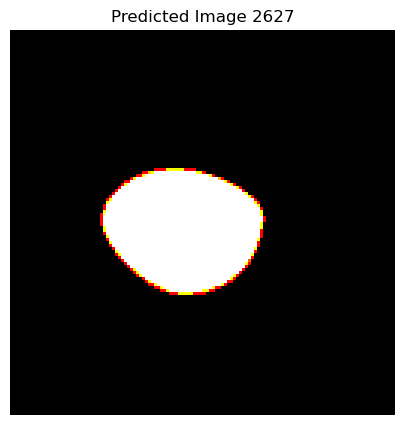

In [118]:
i = np.random.randint(len(mask_test))
# Display the selected ground truth and predicted mask
plt.figure(figsize=(5, 5))
plt.imshow(predictions[i], cmap='gray')  # Change to `mask_train[i]` to see the ground truth
plt.title(f"Predicted Image {i}")
plt.axis("off")
plt.show()

In [ ]:
import tensorflow as tf
from keras.applications import MobileNetV2
from keras.layers import (Conv2D, Conv2DTranspose, Dropout, BatchNormalization, 
                          concatenate, Input, LeakyReLU, Add)
from keras.models import Model

Name = "Enhanced_MobileNetV2_U-NetPP"

# Function to create a residual convolutional block
def conv_block(inputs, num_filters, dropout_rate=0.2):
    shortcut = Conv2D(num_filters, (1, 1), padding="same")(inputs)  # Adjust channels
    shortcut = BatchNormalization()(shortcut)

    x = Conv2D(num_filters, (3, 3), padding="same")(inputs)
    x = BatchNormalization()(x)
    x = LeakyReLU(alpha=0.1)(x)
    x = Dropout(dropout_rate)(x)

    x = Conv2D(num_filters, (3, 3), padding="same")(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(alpha=0.1)(x)

    # Residual Connection (Now Shapes Match)
    x = Add()([x, shortcut])  
    return x

# Build the enhanced UNet++
def enhanced_mobilenet_unetpp():
    img_shape = (128, 128, 3)
    mobilenet = MobileNetV2(include_top=False, weights="imagenet", input_shape=img_shape)
    
    for layer in mobilenet.layers:
        layer.trainable = False

    # Encoder (MobileNetV2 feature extraction)
    c1 = mobilenet.get_layer("block_1_expand_relu").output  # 64x64
    c2 = mobilenet.get_layer("block_3_expand_relu").output  # 32x32
    c3 = mobilenet.get_layer("block_6_expand_relu").output  # 16x16
    c4 = mobilenet.get_layer("block_13_expand_relu").output # 8x8
    c5 = mobilenet.get_layer("block_16_project").output     # 4x4 (Bottleneck)

    # **Atrous Convolution in bottleneck for better feature extraction**
    c5 = Conv2D(512, (3, 3), dilation_rate=2, padding="same", activation="relu")(c5)

    # **Decoder (UNet++ with increased filters and residual connections)**
    d4_1 = conv_block(c4, 512)
    d3_1 = conv_block(c3, 256)
    d3_2 = conv_block(concatenate([d3_1, Conv2DTranspose(256, (2, 2), strides=(2, 2), padding="same")(d4_1)]), 256)

    d2_1 = conv_block(c2, 128)
    d2_2 = conv_block(concatenate([d2_1, Conv2DTranspose(128, (2, 2), strides=(2, 2), padding="same")(d3_1)]), 128)
    d2_3 = conv_block(concatenate([d2_1, d2_2, Conv2DTranspose(128, (2, 2), strides=(2, 2), padding="same")(d3_2)]), 128)

    d1_1 = conv_block(c1, 64)
    d1_2 = conv_block(concatenate([d1_1, Conv2DTranspose(64, (2, 2), strides=(2, 2), padding="same")(d2_1)]), 64)
    d1_3 = conv_block(concatenate([d1_1, d1_2, Conv2DTranspose(64, (2, 2), strides=(2, 2), padding="same")(d2_2)]), 64)
    d1_4 = conv_block(concatenate([d1_1, d1_2, d1_3, Conv2DTranspose(64, (2, 2), strides=(2, 2), padding="same")(d2_3)]), 64)

    # **Final upsampling and output**
    u0_1 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding="same")(d1_4)
    c0_1 = conv_block(u0_1, 32, dropout_rate=0.1)
    outputs = Conv2D(3, (1, 1), activation="sigmoid")(c0_1)

    model = Model(inputs=mobilenet.input, outputs=outputs, name="Enhanced_MobileNetV2_UNetPlusPlus")
    return model


2025-03-06 12:20:40.630112: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-06 12:20:40.643299: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-06 12:20:40.659274: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-06 12:20:40.664124: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-06 12:20:40.677667: I tensorflow/core/platform/cpu_feature_guar

In [10]:
def dice_coef(y_true, y_pred, smooth=1e-6):
        y_true_f = tf.keras.backend.flatten(y_true)
        y_pred_f = tf.keras.backend.flatten(y_pred)
        intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
        return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

# IoU (Jaccard Index)
def iou_coef(y_true, y_pred, smooth=1e-6):
        y_true_f = tf.keras.backend.flatten(y_true)
        y_pred_f = tf.keras.backend.flatten(y_pred)
        intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
        union = tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) - intersection
        return (intersection + smooth) / (union + smooth)

def dice_loss(y_true, y_pred):
    smooth = 1.
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

# Model Compilation
model = enhanced_mobilenet_unetpp()
#enhanced_unetpp_model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), 
        loss=dice_loss, 
        metrics=[dice_coef, iou_coef, tf.keras.metrics.Recall(), tf.keras.metrics.Precision()])
#model.summary()



In [11]:
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint
early_stopping_dice = EarlyStopping(monitor="val_dice_coef", mode="max", patience=100, restore_best_weights=True)
early_stopping_iou = EarlyStopping(monitor="val_iou_coef", mode="max", patience=100, restore_best_weights=True)
results = model.fit(x_train,mask_train, validation_split=0.2, batch_size=32, epochs=300,callbacks=[early_stopping_dice, early_stopping_iou])

Epoch 1/300


I0000 00:00:1741236564.539009  396594 service.cc:146] XLA service 0x715080014120 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1741236564.539056  396594 service.cc:154]   StreamExecutor device (0): Tesla V100S-PCIE-32GB, Compute Capability 7.0
2025-03-06 10:19:25.261194: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-03-06 10:19:27.454727: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90101


  1/302 ━━━━━━━━━━━━━━━━━━━━ 4:07:12 49s/step - dice_coef: 0.0120 - iou_coef: 0.0060 - loss: 0.9880 - precision: 0.0081 - recall: 0.6426

I0000 00:00:1741236596.896362  396594 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


301/302 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - dice_coef: 0.4631 - iou_coef: 0.3412 - loss: 0.5369 - precision: 0.1583 - recall: 0.7068

2025-03-06 10:20:48.834902: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_144', 4 bytes spill stores, 4 bytes spill loads



302/302 ━━━━━━━━━━━━━━━━━━━━ 113s 210ms/step - dice_coef: 0.4642 - iou_coef: 0.3422 - loss: 0.5358 - precision: 0.1591 - recall: 0.7068 - val_dice_coef: 0.6787 - val_iou_coef: 0.5286 - val_loss: 0.3207 - val_precision: 0.6565 - val_recall: 0.8155
Epoch 2/300
302/302 ━━━━━━━━━━━━━━━━━━━━ 26s 85ms/step - dice_coef: 0.7623 - iou_coef: 0.6186 - loss: 0.2377 - precision: 0.7781 - recall: 0.7564 - val_dice_coef: 0.7288 - val_iou_coef: 0.5853 - val_loss: 0.2711 - val_precision: 0.7356 - val_recall: 0.7712
Epoch 3/300
302/302 ━━━━━━━━━━━━━━━━━━━━ 26s 85ms/step - dice_coef: 0.7989 - iou_coef: 0.6683 - loss: 0.2011 - precision: 0.8143 - recall: 0.7947 - val_dice_coef: 0.6335 - val_iou_coef: 0.4814 - val_loss: 0.3622 - val_precision: 0.5747 - val_recall: 0.8156
Epoch 4/300
302/302 ━━━━━━━━━━━━━━━━━━━━ 26s 85ms/step - dice_coef: 0.8049 - iou_coef: 0.6761 - loss: 0.1951 - precision: 0.8256 - recall: 0.7969 - val_dice_coef: 0.7260 - val_iou_coef: 0.5805 - val_loss: 0.2732 - val_precision: 0.7270 - v

In [ ]:
predictions = model.predict(x_train)
test_results = model.evaluate(x_test, mask_test, batch_size=32)
print("Test Metrics:", test_results)

377/377 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step
110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - dice_coef: 0.7191 - iou_coef: 0.5847 - loss: 0.2808 - precision: 0.7606 - recall: 0.7553
Test Metrics: [0.2514600157737732, 0.7434684634208679, 0.6087607145309448, 0.7506970167160034, 0.6725695133209229]


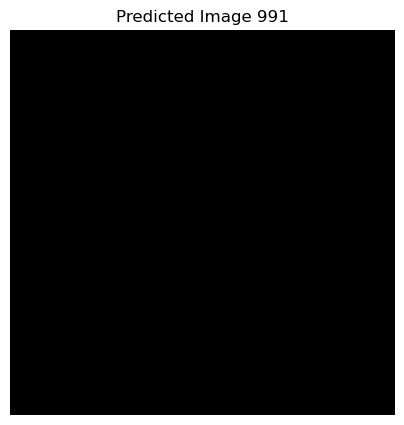

In [68]:
i = np.random.randint(len(mask_test))
# Display the selected ground truth and predicted mask
plt.figure(figsize=(5, 5))
plt.imshow(predictions[i], cmap='gray')  # Change to `mask_train[i]` to see the ground truth
plt.title(f"Predicted Image {i}")
plt.axis("off")
plt.show()

Dropout + Augment

In [ ]:
import tensorflow as tf
from keras.applications import MobileNetV2
from keras.layers import (Conv2D, Conv2DTranspose, Dropout, BatchNormalization, concatenate, Input, RandomFlip, RandomRotation, RandomZoom, RandomContrast)
from keras.models import Model

Name = "MobileNetV2_U-NetPP"

def conv_block(inputs, num_filters, dropout_rate=0.3):
    x = Conv2D(num_filters, (3, 3), activation="relu", padding="same")(inputs)
    x = BatchNormalization(axis=-1)(x)  # 👈 Ensure NHWC format
    x = Dropout(dropout_rate, training=True)(x)  # 👈 Fix Dropout issue
    x = Conv2D(num_filters, (3, 3), activation="relu", padding="same")(x)
    x = BatchNormalization(axis=-1)(x)  # 👈 Ensure NHWC format
    x = Dropout(dropout_rate, training=True)(x)  # 👈 Fix Dropout issue
    return x

def mobilenet_unetpp():
    img_shape = (128, 128, 3)
    inputs = Input(shape=img_shape)

    # Data Augmentation Layer (Applied to Input)
    x = RandomFlip("horizontal")(inputs)
    x = RandomRotation(0.1)(x)
    x = RandomZoom(0.2)(x)
    x = RandomContrast(0.2)(x)

    # Encoder (MobileNetV2 features)
    mobilenet = MobileNetV2(include_top=False, weights="imagenet", input_tensor=inputs)  # 👈 Fix input

    for layer in mobilenet.layers:
        layer.trainable = False

    c1 = mobilenet.get_layer("block_1_expand_relu").output  # 64x64
    c2 = mobilenet.get_layer("block_3_expand_relu").output  # 32x32
    c3 = mobilenet.get_layer("block_6_expand_relu").output  # 16x16
    c4 = mobilenet.get_layer("block_13_expand_relu").output # 8x8
    c5 = mobilenet.get_layer("block_16_project").output     # 4x4 (Bottleneck)

    # Nested Decoder (UNet++)
    d4_1 = conv_block(c4, 256)
    d3_1 = conv_block(c3, 128)
    d3_2 = conv_block(concatenate([d3_1, Conv2DTranspose(128, (2, 2), strides=(2, 2), padding="same")(d4_1)]), 128)
    d2_1 = conv_block(c2, 64)
    d2_2 = conv_block(concatenate([d2_1, Conv2DTranspose(64, (2, 2), strides=(2, 2), padding="same")(d3_1)]), 64)
    d2_3 = conv_block(concatenate([d2_1, d2_2, Conv2DTranspose(64, (2, 2), strides=(2, 2), padding="same")(d3_2)]), 64)
    d1_1 = conv_block(c1, 32)
    d1_2 = conv_block(concatenate([d1_1, Conv2DTranspose(32, (2, 2), strides=(2, 2), padding="same")(d2_1)]), 32)
    d1_3 = conv_block(concatenate([d1_1, d1_2, Conv2DTranspose(32, (2, 2), strides=(2, 2), padding="same")(d2_2)]), 32)
    d1_4 = conv_block(concatenate([d1_1, d1_2, d1_3, Conv2DTranspose(32, (2, 2), strides=(2, 2), padding="same")(d2_3)]), 32)
    
    # Final upsampling and output
    u0_1 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding="same")(d1_4)
    c0_1 = conv_block(u0_1, 16, dropout_rate=0.2)
    outputs = Conv2D(3, (1, 1), activation="sigmoid")(c0_1)
    
    model = Model(inputs=inputs, outputs=outputs, name="MobileNetV2_UNetPlusPlus")
    return model

# Create the model
unetpp_model = mobilenet_unetpp()
unetpp_model.summary()



In [5]:
def dice_coef(y_true, y_pred, smooth=1e-6):
        y_true_f = tf.keras.backend.flatten(y_true)
        y_pred_f = tf.keras.backend.flatten(y_pred)
        intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
        return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

# IoU (Jaccard Index)
def iou_coef(y_true, y_pred, smooth=1e-6):
        y_true_f = tf.keras.backend.flatten(y_true)
        y_pred_f = tf.keras.backend.flatten(y_pred)
        intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
        union = tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) - intersection
        return (intersection + smooth) / (union + smooth)

def dice_loss(y_true, y_pred):
    smooth = 1.
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

# Model Compilation
model= mobilenet_unetpp()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), 
        loss=dice_loss, 
        metrics=[dice_coef, iou_coef, tf.keras.metrics.Recall(), tf.keras.metrics.Precision()])
#model.summary()


/tmp/ipykernel_484627/1376879483.py:28: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet = MobileNetV2(include_top=False, weights="imagenet", input_tensor=x)


In [6]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
checkpointer = ModelCheckpoint(Name + '_checkpoint.weights.h5', verbose=1, save_best_only=True, save_weights_only=True)

In [7]:
early_stopping_dice = EarlyStopping(monitor="val_dice_coef", mode="max", patience=100, restore_best_weights=True)
early_stopping_iou = EarlyStopping(monitor="val_iou_coef", mode="max", patience=100, restore_best_weights=True)


In [11]:
results = model.fit(x_train,mask_train, validation_split=0.2, batch_size=32, epochs=300,callbacks=[early_stopping_dice, early_stopping_iou])

Epoch 1/300
302/302 ━━━━━━━━━━━━━━━━━━━━ 30s 99ms/step - dice_coef: 0.7119 - iou_coef: 0.5549 - loss: 0.2881 - precision: 0.7314 - recall: 0.7064 - val_dice_coef: 0.6969 - val_iou_coef: 0.5453 - val_loss: 0.3038 - val_precision: 0.7362 - val_recall: 0.6981
Epoch 2/300
302/302 ━━━━━━━━━━━━━━━━━━━━ 29s 96ms/step - dice_coef: 0.7167 - iou_coef: 0.5604 - loss: 0.2833 - precision: 0.7231 - recall: 0.7214 - val_dice_coef: 0.6697 - val_iou_coef: 0.5148 - val_loss: 0.3310 - val_precision: 0.6448 - val_recall: 0.7659
Epoch 3/300
302/302 ━━━━━━━━━━━━━━━━━━━━ 29s 95ms/step - dice_coef: 0.7208 - iou_coef: 0.5660 - loss: 0.2792 - precision: 0.7309 - recall: 0.7220 - val_dice_coef: 0.6849 - val_iou_coef: 0.5341 - val_loss: 0.3161 - val_precision: 0.7481 - val_recall: 0.6607
Epoch 4/300
302/302 ━━━━━━━━━━━━━━━━━━━━ 29s 95ms/step - dice_coef: 0.7277 - iou_coef: 0.5739 - loss: 0.2723 - precision: 0.7367 - recall: 0.7294 - val_dice_coef: 0.6586 - val_iou_coef: 0.5029 - val_loss: 0.3423 - val_precision: 

In [12]:
test_results = model.evaluate(x_test, mask_test, batch_size=32)
print("Test Metrics:", test_results)

110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - dice_coef: 0.6696 - iou_coef: 0.5258 - loss: 0.3304 - precision: 0.6979 - recall: 0.7286
Test Metrics: [0.2934577763080597, 0.7070379257202148, 0.5592093467712402, 0.7273889183998108, 0.7286586165428162]


UNFREEZE MOBILENET LAYERS

In [4]:
import tensorflow as tf
from keras.applications import MobileNetV2
from keras.layers import (Conv2D, Conv2DTranspose, Dropout, BatchNormalization, concatenate, Input)
from keras.models import Model

Name = "MobileNetV2_U-NetPP"

def conv_block(inputs, num_filters, dropout_rate=0.3):
    x = Conv2D(num_filters, (3, 3), activation="relu", padding="same")(inputs)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)
    x = Conv2D(num_filters, (3, 3), activation="relu", padding="same")(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)
    return x

def mobilenet_unetpp():
    img_shape = (128, 128, 3)
    mobilenet = MobileNetV2(include_top=False, weights="imagenet", input_shape=img_shape)
    
    for layer in mobilenet.layers[-30:]:  # Unfreeze last 30 layers
        layer.trainable = True

    # Encoder (MobileNetV2 features)
    c1 = mobilenet.get_layer("block_1_expand_relu").output  # 64x64
    c2 = mobilenet.get_layer("block_3_expand_relu").output  # 32x32
    c3 = mobilenet.get_layer("block_6_expand_relu").output  # 16x16
    c4 = mobilenet.get_layer("block_13_expand_relu").output # 8x8
    c5 = mobilenet.get_layer("block_16_project").output     # 4x4 (Bottleneck)

    # Nested Decoder (UNet++)
    d4_1 = conv_block(c4, 256)
    d3_1 = conv_block(c3, 128)
    d3_2 = conv_block(concatenate([d3_1, Conv2DTranspose(128, (2, 2), strides=(2, 2), padding="same")(d4_1)]), 128)
    d2_1 = conv_block(c2, 64)
    d2_2 = conv_block(concatenate([d2_1, Conv2DTranspose(64, (2, 2), strides=(2, 2), padding="same")(d3_1)]), 64)
    d2_3 = conv_block(concatenate([d2_1, d2_2, Conv2DTranspose(64, (2, 2), strides=(2, 2), padding="same")(d3_2)]), 64)
    d1_1 = conv_block(c1, 32)
    d1_2 = conv_block(concatenate([d1_1, Conv2DTranspose(32, (2, 2), strides=(2, 2), padding="same")(d2_1)]), 32)
    d1_3 = conv_block(concatenate([d1_1, d1_2, Conv2DTranspose(32, (2, 2), strides=(2, 2), padding="same")(d2_2)]), 32)
    d1_4 = conv_block(concatenate([d1_1, d1_2, d1_3, Conv2DTranspose(32, (2, 2), strides=(2, 2), padding="same")(d2_3)]), 32)
    
    # Final upsampling and output
    u0_1 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding="same")(d1_4)
    c0_1 = conv_block(u0_1, 16, dropout_rate=0.2)
    outputs = Conv2D(3, (1, 1), activation="sigmoid")(c0_1)
    
    model = Model(inputs=mobilenet.input, outputs=outputs, name="MobileNetV2_UNetPlusPlus")
    return model

# Create the model
unetpp_model = mobilenet_unetpp()
unetpp_model.summary()


2025-03-07 12:16:18.561665: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 31134 MB memory:  -> device: 0, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:3b:00.0, compute capability: 7.0


Model: "MobileNetV2_UNetPlusPlus"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 4,106,243 (15.66 MB)

 Trainable params: 4,085,571 (15.59 MB)

 Non-trainable params: 20,672 (80.75 KB)

In [6]:
def dice_coef(y_true, y_pred, smooth=1e-6):
        y_true_f = tf.keras.backend.flatten(y_true)
        y_pred_f = tf.keras.backend.flatten(y_pred)
        intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
        return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

# IoU (Jaccard Index)
def iou_coef(y_true, y_pred, smooth=1e-6):
        y_true_f = tf.keras.backend.flatten(y_true)
        y_pred_f = tf.keras.backend.flatten(y_pred)
        intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
        union = tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) - intersection
        return (intersection + smooth) / (union + smooth)

def dice_loss(y_true, y_pred):
    smooth = 1.
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)


In [7]:

# Model Compilation
model= mobilenet_unetpp()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), 
        loss=dice_loss, 
        metrics=[dice_coef, iou_coef, tf.keras.metrics.Recall(), tf.keras.metrics.Precision()])
#model.summary()

In [11]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
checkpointer = ModelCheckpoint(Name + '_checkpoint.weights.h5', verbose=1, save_best_only=True, save_weights_only=True)
from keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_dice_coeff',  # Ensure this matches the metric name in your model
    patience=10,  # Adjust as needed
    mode='max',  # Explicitly maximize Dice coefficient
    verbose=1
)


In [12]:
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint

results = model.fit(
    x_train, mask_train, 
    validation_split=0.2, 
    batch_size=32, 
    epochs=300, 
    callbacks=[early_stopping, checkpointer]
)

Epoch 1/300
301/302 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - dice_coef: 0.7601 - iou_coef: 0.6163 - loss: 0.2399 - precision: 0.7763 - recall: 0.7583
Epoch 1: val_loss improved from inf to 0.70448, saving model to MobileNetV2_U-NetPP_checkpoint.weights.h5


/home/gourib/mnt/sdb/conds_envs/newk/lib/python3.9/site-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_dice_coeff` which is not available. Available metrics are: dice_coef,iou_coef,loss,precision,recall,val_dice_coef,val_iou_coef,val_loss,val_precision,val_recall
  current = self.get_monitor_value(logs)


302/302 ━━━━━━━━━━━━━━━━━━━━ 29s 95ms/step - dice_coef: 0.7600 - iou_coef: 0.6163 - loss: 0.2400 - precision: 0.7762 - recall: 0.7583 - val_dice_coef: 0.2938 - val_iou_coef: 0.1841 - val_loss: 0.7045 - val_precision: 0.1995 - val_recall: 0.7766
Epoch 2/300
301/302 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - dice_coef: 0.7627 - iou_coef: 0.6199 - loss: 0.2373 - precision: 0.7757 - recall: 0.7633
Epoch 2: val_loss improved from 0.70448 to 0.42421, saving model to MobileNetV2_U-NetPP_checkpoint.weights.h5
302/302 ━━━━━━━━━━━━━━━━━━━━ 22s 74ms/step - dice_coef: 0.7627 - iou_coef: 0.6199 - loss: 0.2373 - precision: 0.7757 - recall: 0.7633 - val_dice_coef: 0.5752 - val_iou_coef: 0.4217 - val_loss: 0.4242 - val_precision: 0.5268 - val_recall: 0.7732
Epoch 3/300
301/302 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - dice_coef: 0.7685 - iou_coef: 0.6275 - loss: 0.2315 - precision: 0.7877 - recall: 0.7615
Epoch 3: val_loss did not improve from 0.42421
302/302 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - dice_coef: 0.7685 

In [ ]:
test_results = model.evaluate(x_test, mask_test, batch_size=32)
print("Test Metrics:", test_results)

110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - dice_coef: 0.7180 - iou_coef: 0.5824 - loss: 0.2820 - precision: 0.7161 - recall: 0.8121
Test Metrics: [0.25415176153182983, 0.7462724447250366, 0.6078609824180603, 0.8031688928604126, 0.7426403760910034]


: 

FOCAL LOSS 

In [ ]:
import tensorflow as tf
from keras.applications import MobileNetV2
from keras.layers import (Conv2D, Conv2DTranspose, Dropout, BatchNormalization, concatenate, Input)
from keras.models import Model

Name = "MobileNetV2_U-NetPP"

def conv_block(inputs, num_filters, dropout_rate=0.3):
    x = Conv2D(num_filters, (3, 3), activation="relu", padding="same")(inputs)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)
    x = Conv2D(num_filters, (3, 3), activation="relu", padding="same")(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)
    return x

def mobilenet_unetpp():
    img_shape = (128, 128, 3)
    mobilenet = MobileNetV2(include_top=False, weights="imagenet", input_shape=img_shape)
    
    for layer in mobilenet.layers:
        layer.trainable = False

    # Encoder (MobileNetV2 features)
    c1 = mobilenet.get_layer("block_1_expand_relu").output  # 64x64
    c2 = mobilenet.get_layer("block_3_expand_relu").output  # 32x32
    c3 = mobilenet.get_layer("block_6_expand_relu").output  # 16x16
    c4 = mobilenet.get_layer("block_13_expand_relu").output # 8x8
    c5 = mobilenet.get_layer("block_16_project").output     # 4x4 (Bottleneck)

    # Nested Decoder (UNet++)
    d4_1 = conv_block(c4, 256)
    d3_1 = conv_block(c3, 128)
    d3_2 = conv_block(concatenate([d3_1, Conv2DTranspose(128, (2, 2), strides=(2, 2), padding="same")(d4_1)]), 128)
    d2_1 = conv_block(c2, 64)
    d2_2 = conv_block(concatenate([d2_1, Conv2DTranspose(64, (2, 2), strides=(2, 2), padding="same")(d3_1)]), 64)
    d2_3 = conv_block(concatenate([d2_1, d2_2, Conv2DTranspose(64, (2, 2), strides=(2, 2), padding="same")(d3_2)]), 64)
    d1_1 = conv_block(c1, 32)
    d1_2 = conv_block(concatenate([d1_1, Conv2DTranspose(32, (2, 2), strides=(2, 2), padding="same")(d2_1)]), 32)
    d1_3 = conv_block(concatenate([d1_1, d1_2, Conv2DTranspose(32, (2, 2), strides=(2, 2), padding="same")(d2_2)]), 32)
    d1_4 = conv_block(concatenate([d1_1, d1_2, d1_3, Conv2DTranspose(32, (2, 2), strides=(2, 2), padding="same")(d2_3)]), 32)
    
    # Final upsampling and output
    u0_1 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding="same")(d1_4)
    c0_1 = conv_block(u0_1, 16, dropout_rate=0.2)
    outputs = Conv2D(3, (1, 1), activation="sigmoid")(c0_1)
    
    model = Model(inputs=mobilenet.input, outputs=outputs, name="MobileNetV2_UNetPlusPlus")
    return model

# Create the model
unetpp_model = mobilenet_unetpp()
unetpp_model.summary()


In [ ]:
import tensorflow.keras.backend as K

def dice_loss(y_true, y_pred):
    smooth = 1.0
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return 1 - ((2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth))


In [ ]:
def dice_coef(y_true, y_pred, smooth=1e-6):
        y_true_f = tf.keras.backend.flatten(y_true)
        y_pred_f = tf.keras.backend.flatten(y_pred)
        intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
        return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

# IoU (Jaccard Index)
def iou_coef(y_true, y_pred, smooth=1e-6):
        y_true_f = tf.keras.backend.flatten(y_true)
        y_pred_f = tf.keras.backend.flatten(y_pred)
        intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
        union = tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) - intersection
        return (intersection + smooth) / (union + smooth)

def dice_loss(y_true, y_pred):
    smooth = 1.
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)


In [ ]:
import tensorflow.keras.backend as K

def focal_loss(alpha=0.25, gamma=2.0):
    def loss(y_true, y_pred):
        epsilon = K.epsilon()  # Small value to prevent log(0)
        y_pred = K.clip(y_pred, epsilon, 1.0 - epsilon)  # Clip predictions
        pt = y_true * y_pred + (1 - y_true) * (1 - y_pred)  # Probabilities
        focal_weight = alpha * y_true + (1 - alpha) * (1 - y_true)  # Weighting factor
        loss = -focal_weight * K.pow((1 - pt), gamma) * K.log(pt)  # Focal Loss formula
        return K.mean(loss)
    return loss


In [ ]:

# Model Compilation
model= mobilenet_unetpp()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), 
        loss=focal_loss(alpha=0.25, gamma=2.0), 
        metrics=[dice_coef, iou_coef, tf.keras.metrics.Recall(), tf.keras.metrics.Precision()])
#model.summary()

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
checkpointer = ModelCheckpoint(Name + '_checkpoint.weights.h5', verbose=1, save_best_only=True, save_weights_only=True)
early_stopping = EarlyStopping(monitor='val_dice_coeff', patience=5, verbose=1, restore_best_weights=True)

In [ ]:
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint

results = model.fit(
    x_train, mask_train, 
    validation_split=0.2, 
    batch_size=32, 
    epochs=300, 
    callbacks=[early_stopping, checkpointer]
)